# 02 — Capacity Fade Analysis

This notebook demonstrates how to:
1. Load capacity fade curves for **all 20 deep-cycling cells**
2. Overlay fade curves by group to visualise degradation trends
3. **Isolate the temperature effect** (G1 vs G2 — ambient vs 40 °C at 1C)
4. **Isolate the C-rate effect** (G2 vs G3 — 1C vs 2C at 40 °C)
5. **Quantify cell-to-cell variability** within G1
6. Compute capacity retention statistics per group

In [9]:
import sys, os
sys.path.insert(0, os.path.abspath("."))

from sit_utils import SITDataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_ROOT = os.path.abspath("../Data")
ds = SITDataset(DATA_ROOT)
print(ds)

SITDataset(root='c:\Users\abhirami\OneDrive - Newcastle University\Phd\PhD - Karthickumar\battery\data\SIT_Data\Batery Degradation data NYP\Data', cells=22)


## 1. Load all capacity fade curves

In [2]:
fade_all = ds.capacity_fade_all()
print(f"Total rows: {len(fade_all)}")
print(f"Cells:  {fade_all['cell_id'].nunique()}")
print(f"Groups: {sorted(fade_all['group'].unique())}")
fade_all.head()

Total rows: 14265
Cells:  20
Groups: ['G1', 'G2', 'G3']


,cell_id,group,cycle,capacity_Ah
0,001-1,G1,1.0,52.4512
1,001-1,G1,2.0,52.5153
2,001-1,G1,3.0,52.8847
3,001-1,G1,4.0,53.0278
4,001-1,G1,5.0,52.6791


## 2. All groups overlaid

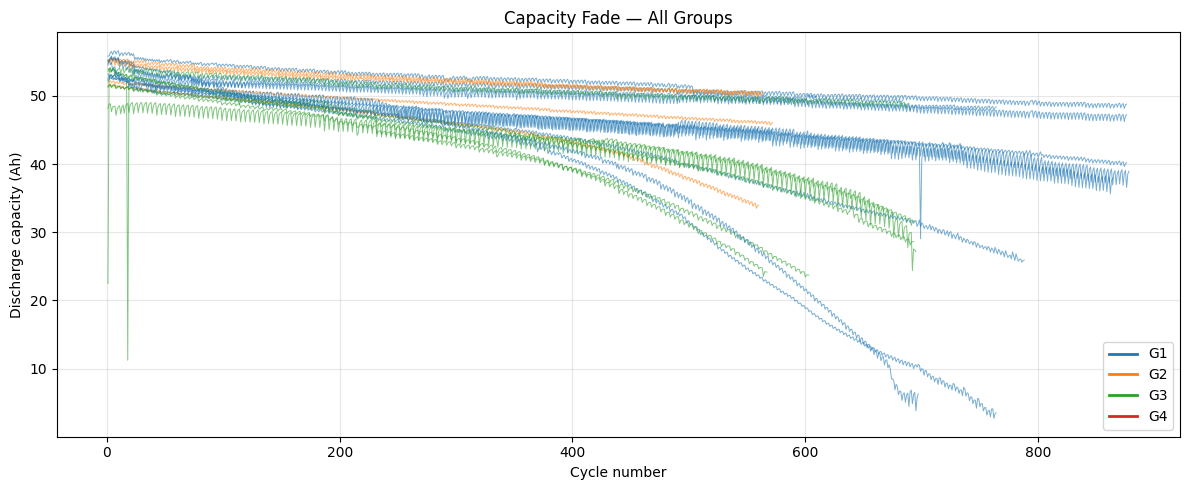

In [3]:
GROUP_COLOURS = {"G1": "#1f77b4", "G2": "#ff7f0e", "G3": "#2ca02c", "G4": "#d62728"}

fig, ax = plt.subplots(figsize=(12, 5))
for cell_id, cdf in fade_all.groupby("cell_id"):
    grp = cdf["group"].iloc[0]
    ax.plot(cdf["cycle"], cdf["capacity_Ah"],
            linewidth=0.7, alpha=0.6, color=GROUP_COLOURS.get(grp, "gray"))

# Group-level legend
for g, c in GROUP_COLOURS.items():
    ax.plot([], [], color=c, linewidth=2, label=g)
ax.legend()
ax.set_xlabel("Cycle number")
ax.set_ylabel("Discharge capacity (Ah)")
ax.set_title("Capacity Fade — All Groups")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Temperature effect — G1 (ambient) vs G2 (40 °C)

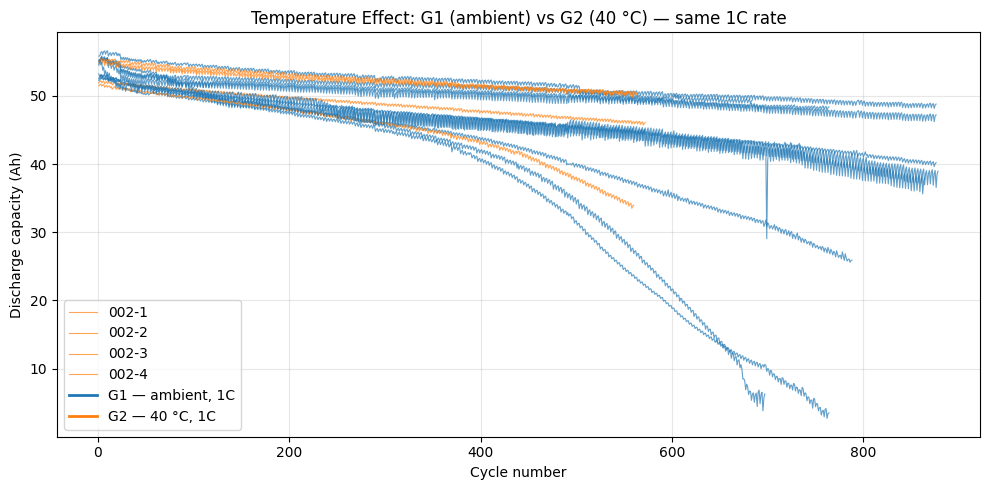

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
for cell_id, cdf in fade_all[fade_all["group"].isin(["G1", "G2"])].groupby("cell_id"):
    grp = cdf["group"].iloc[0]
    ax.plot(cdf["cycle"], cdf["capacity_Ah"],
            linewidth=0.8, alpha=0.7,
            color=GROUP_COLOURS[grp],
            label=f"{cell_id}" if grp == "G2" else None)

ax.plot([], [], color=GROUP_COLOURS["G1"], linewidth=2, label="G1 — ambient, 1C")
ax.plot([], [], color=GROUP_COLOURS["G2"], linewidth=2, label="G2 — 40 °C, 1C")
ax.legend(loc="lower left")
ax.set_xlabel("Cycle number")
ax.set_ylabel("Discharge capacity (Ah)")
ax.set_title("Temperature Effect: G1 (ambient) vs G2 (40 °C) — same 1C rate")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. C-rate effect — G2 (1C) vs G3 (2C)

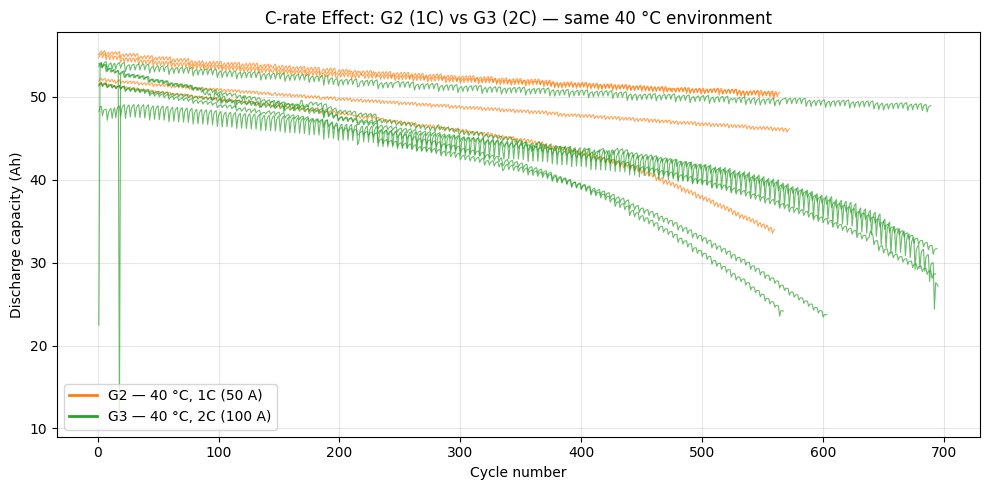

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for cell_id, cdf in fade_all[fade_all["group"].isin(["G2", "G3"])].groupby("cell_id"):
    grp = cdf["group"].iloc[0]
    ax.plot(cdf["cycle"], cdf["capacity_Ah"],
            linewidth=0.8, alpha=0.7, color=GROUP_COLOURS[grp])

ax.plot([], [], color=GROUP_COLOURS["G2"], linewidth=2, label="G2 — 40 °C, 1C (50 A)")
ax.plot([], [], color=GROUP_COLOURS["G3"], linewidth=2, label="G3 — 40 °C, 2C (100 A)")
ax.legend(loc="lower left")
ax.set_xlabel("Cycle number")
ax.set_ylabel("Discharge capacity (Ah)")
ax.set_title("C-rate Effect: G2 (1C) vs G3 (2C) — same 40 °C environment")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Cell-to-cell variability within G1

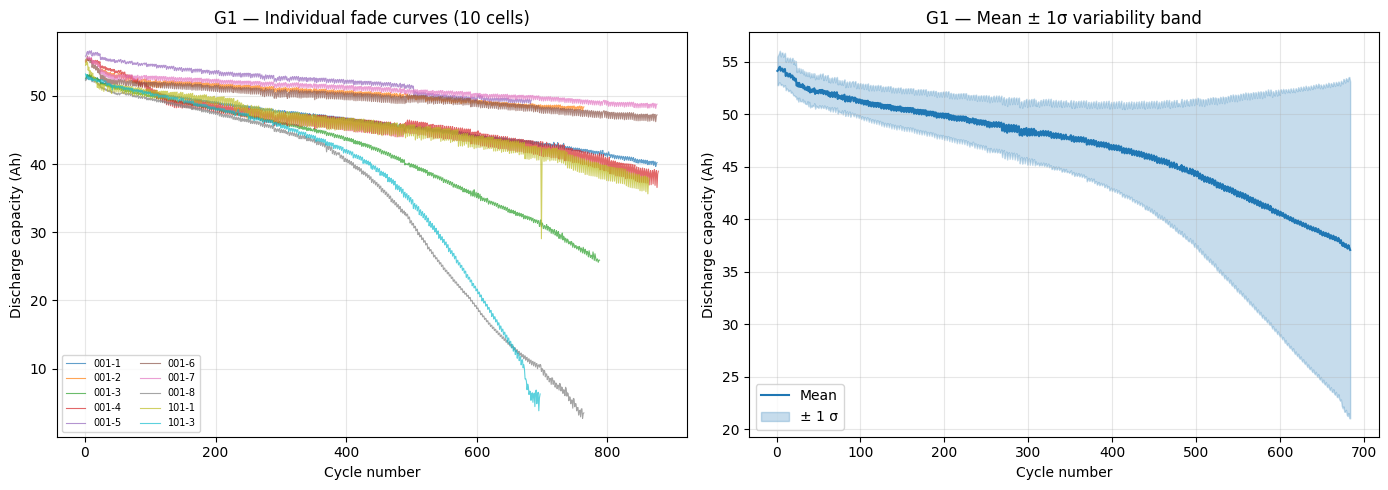

In [6]:
g1_fade = fade_all[fade_all["group"] == "G1"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlay all G1 cells
for cell_id, cdf in g1_fade.groupby("cell_id"):
    axes[0].plot(cdf["cycle"], cdf["capacity_Ah"],
                 linewidth=0.8, alpha=0.7, label=cell_id)
axes[0].legend(fontsize=7, ncol=2)
axes[0].set_xlabel("Cycle number")
axes[0].set_ylabel("Discharge capacity (Ah)")
axes[0].set_title("G1 — Individual fade curves (10 cells)")
axes[0].grid(True, alpha=0.3)

# Right: mean ± std band
# Align to common cycle range
max_common = g1_fade.groupby("cell_id")["cycle"].max().min()
g1_trunc = g1_fade[g1_fade["cycle"] <= max_common]
g1_stats = g1_trunc.groupby("cycle")["capacity_Ah"].agg(["mean", "std"]).reset_index()

axes[1].plot(g1_stats["cycle"], g1_stats["mean"], color="#1f77b4", linewidth=1.5, label="Mean")
axes[1].fill_between(g1_stats["cycle"],
                      g1_stats["mean"] - g1_stats["std"],
                      g1_stats["mean"] + g1_stats["std"],
                      alpha=0.25, color="#1f77b4", label="± 1 σ")
axes[1].legend()
axes[1].set_xlabel("Cycle number")
axes[1].set_ylabel("Discharge capacity (Ah)")
axes[1].set_title("G1 — Mean ± 1σ variability band")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Capacity retention statistics

In [7]:
summary = ds.summary()
summary = summary.sort_values(["group", "cell_id"]).reset_index(drop=True)
summary

,cell_id,group,tester,total_cycles,initial_capacity_Ah,final_capacity_Ah,retention_pct
0,001-1,G1,Repower_001,876,52.4512,40.2198,76.68
1,001-2,G1,Repower_001,764,55.1070,48.3862,87.80
2,001-3,G1,Repower_001,788,52.5996,25.9132,49.27
3,001-4,G1,Repower_001,878,54.9594,38.9621,70.89
4,001-5,G1,Repower_001,684,55.8289,49.4038,88.49
5,001-6,G1,Repower_001,876,55.2570,47.2159,85.45
6,001-7,G1,Repower_001,876,55.1360,48.7984,88.51
7,001-8,G1,Repower_001,764,52.2448,3.5061,6.71
8,101-1,G1,Chroma_101,864,54.4841,37.9283,69.61
9,101-3,G1,Chroma_101,697,53.2165,6.2825,11.81


In [8]:
# Group-level statistics
group_stats = summary.groupby("group").agg(
    n_cells=("cell_id", "count"),
    mean_initial=("initial_capacity_Ah", "mean"),
    mean_final=("final_capacity_Ah", "mean"),
    mean_retention=("retention_pct", "mean"),
    std_retention=("retention_pct", "std"),
    min_retention=("retention_pct", "min"),
    max_retention=("retention_pct", "max"),
).round(2)
group_stats

,n_cells,mean_initial,mean_final,mean_retention,std_retention,min_retention,max_retention
group,,,,,,,
G1,10,54.13,34.66,63.52,31.07,6.71,88.51
G2,4,53.29,45.25,84.68,12.56,65.97,92.38
G3,6,46.81,30.71,69.31,24.24,46.15,107.50
G4,2,NaN,NaN,NaN,NaN,NaN,NaN


---
**Next:** `03_feature_extraction.ipynb` — Extract ML-ready health indicators from the raw cycle data.